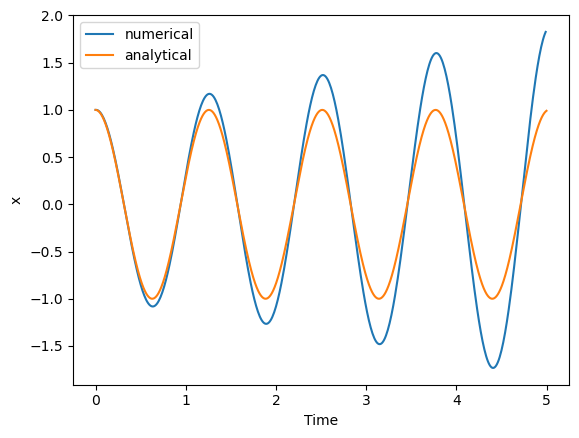

In [87]:
import matplotlib.pyplot as plt
import math
import numpy as np
def numerical(x0=1, v0=0, dt=0.01, t=5, w0=5, tao=10000000000, A=0, wd=10, k=25, m=1):
    t_list = np.arange(0,t,dt)
    x_list =[x0]
    v_list =[v0]
    e_list =[(m/2)*(v0**2)+(k/2)*(x0**2)]
    ek_list = [0.5*m*v0**2]
    ep_list = [0.5*k*(x0)**2]
    w_list = [-tao**(-1)*v0**2*dt]
    x=x0
    v=v0
    for t in t_list:
        v = v_list[-1] -(((k/m)**0.5)**2)*dt*x_list[-1] - dt*v_list[-1]/tao + dt*A*np.cos(wd*(t-dt))
        x = x_list[-1]+dt*v_list[-1]
        E = (m/2)*v**2 + (k/2)*x**2
        Ek = 0.5*m*v**2
        Ep = 0.5*k*(x)**2
        w = -tao**(-1)*v**2*dt
        x_list.append(x)
        v_list.append(v)
        e_list.append(E)
        ek_list.append(Ek)
        ep_list.append(Ep)
        w_list.append(w)
        
    return t_list, x_list[:-1], e_list[:-1], v_list[:-1], ek_list[:-1], ep_list[:-1], w_list[:-1]
    
    
def analytical(x0=1, w0=5, dt=0.001, t=5):
    t_list=np.arange(0, t,dt)
    x_list=[]
    x=x0
    for t in t_list:
        x = x0*np.cos(w0*t)
        x_list.append(x)
    return t_list, x_list

t_num, x_num, i, _, _, _, _ = numerical()
t_ana, x_ana = analytical()

plt.plot(t_num, x_num, label="numerical")
plt.plot(t_ana, x_ana, label="analytical")
plt.xlabel("Time")
plt.ylabel("x")
plt.legend()
plt.show()

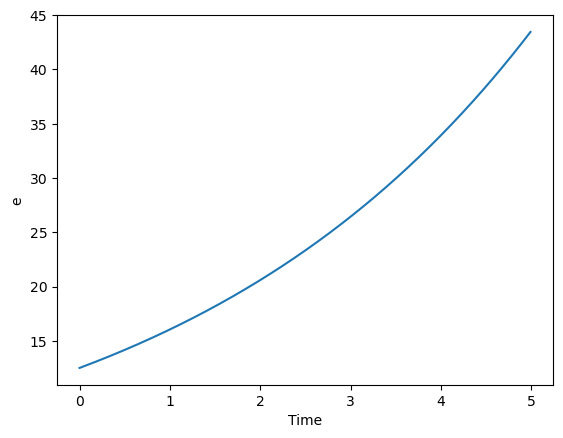

In [37]:
t_num, x_num, e_list, _ = numerical()

plt.plot(t_num, e_list)
plt.xlabel("Time")
plt.ylabel("e")
plt.show()

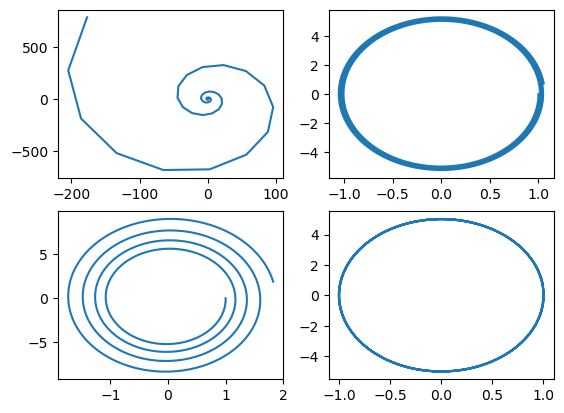

In [57]:
t_num, x_num, e_list, v_list = numerical(dt=0.1)
fig, ax = plt.subplots(2,2)

ax[0,0].plot(x_num, v_list, label="0.1")

t_num, x_num, e_list, v_list = numerical(dt=0.01)
ax[1,0].plot(x_num, v_list, label="0.01")
t_num, x_num, e_list, v_list = numerical(dt=0.001)
ax[0,1].plot(x_num, v_list, label="0.001")

t_num, x_num, e_list, v_list = numerical(dt=0.0001)
ax[1,1].plot(x_num, v_list, label="0.0001")

plt.show()

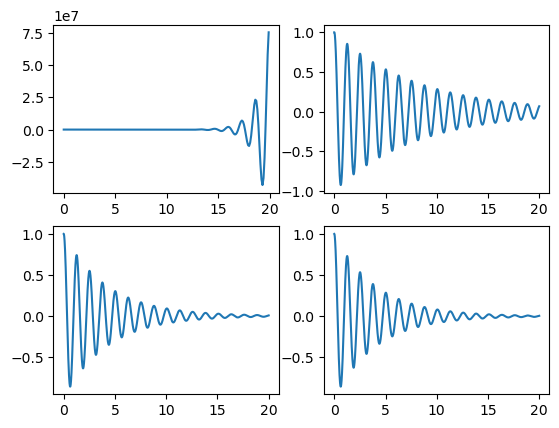

In [69]:
fig, ax = plt.subplots(2,2)
t_list, x_list, e_list, v_list = numerical(dt=0.1, tao=2, t=20)
ax[0,0].plot(t_list, x_list)
t_list, x_list, e_list, v_list = numerical(dt=0.01, tao=2, t=20)
ax[0,1].plot(t_list, x_list)
t_list, x_list, e_list, v_list = numerical(dt=0.001, tao=2, t=20)
ax[1,0].plot(t_list, x_list)
t_list, x_list, e_list, v_list = numerical(dt=0.0001, tao=2, t=20)
ax[1,1].plot(t_list, x_list)
plt.show()

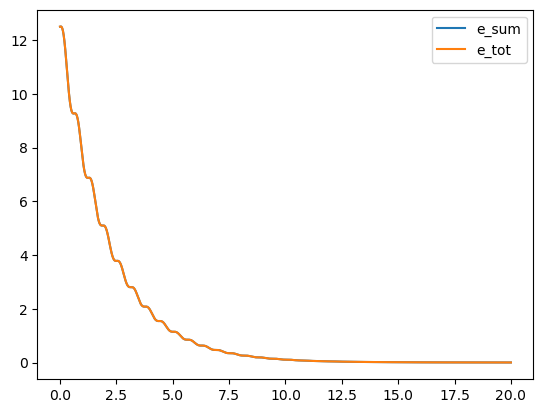

In [85]:
t_list, x_list, e_list, v_list, ek_list, ep_list = numerical(dt=0.001, tao=2, t=20)
sum_list =[]
for x in range(len(ek_list)):
    sum=ek_list[x]+ep_list[x]
    sum_list.append(sum)
plt.plot(t_list, sum_list, label="e_sum")
plt.plot(t_list, e_list, label="e_tot")
plt.legend()
plt.show()




In [92]:
t_list, x_list, e_list, v_list, ek_list, ep_list, w_list = numerical(dt=0.0001, tao=2, t=20)
w=0
for x in range(len(w_list)):
    w += w_list[x]
print(w)

-12.56224312739564


In [65]:
import matplotlib.pyplot as plt
import math
import numpy as np
t_num, x_num, _ = numerical(tao=1)
plt.plot(t_num, x_num, label="underdampend")
t_num, x_num, _ = numerical(tao=0.0005)
plt.plot(t_num, x_num, label="tao=0.0005")
t_num, x_num, _ = numerical(tao=0.1)
plt.plot(t_num, x_num, label="tao=0.1")
plt.xlabel("Time")
plt.ylabel("x")
plt.legend()
plt.show()

ValueError: too many values to unpack (expected 3)

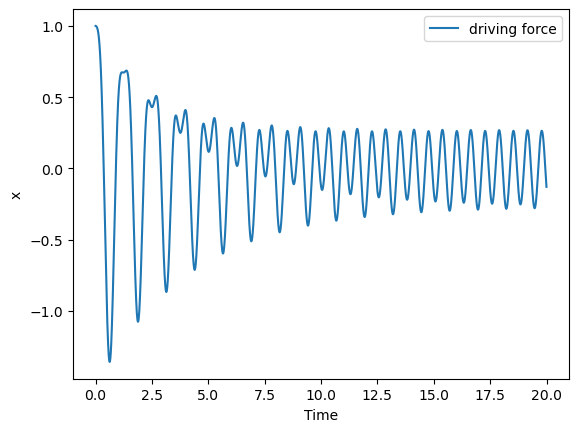

In [124]:
import matplotlib.pyplot as plt
import math
import numpy as np
t_num, x_num = numerical(tao=2, A=20, t=20)
plt.plot(t_num, x_num, label="driving force")
plt.xlabel("Time")
plt.ylabel("x")
plt.legend()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (5000,) and (5001,)

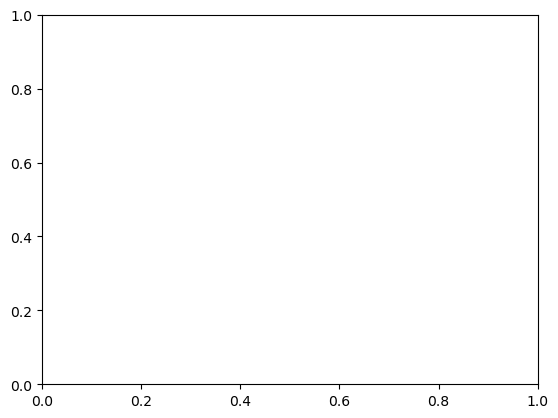

In [11]:
t_num, x_num, e_list = numerical()

plt.plot(t_num, e_list, label="numerical")
plt.xlabel("Time")
plt.ylabel("x")
plt.legend()
plt.show()